Sınıflandırma Nedir?

Makine öğrenmesinde iki ana görev vardır: Regresyon (değer tahmin etme) ve Sınıflandırma (sınıf tahmin etme)
Sınıflandırma: Bir veri noktasının hangi kategoriye ait olduğunu belirleme işlemi
Örneğin: "Bu yazıyla yazılmış sayı '5' midir?" sorusuna Evet/Hayır cevabı vermek

1.1 MNIST Nedir?

MNIST: 70.000 adet el yazısı rakam görseli

Her görsel 28×28 piksel boyutunda

Her rakam 0-9 arasında bir değerle etiketlenmiş

Makine Öğrenmesinin "Merhaba Dünya"sı diye bilinen bir veri seti

1.2 Veri Setini İndirme ve Yükleme

In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

Kod Açıklaması:

In [4]:
from sklearn.datasets import fetch_openml

from sklearn.datasets: Scikit-Learn kütüphanesinden datasets (veri setleri) modülünü import ediyoruz

import fetch_openml: fetch_openml fonksiyonunu içe aktarıyoruz. Bu fonksiyon OpenML.org web sitesinden veri indirmek için kullanılır

In [5]:
mnist = fetch_openml('mnist_784', as_frame=False)

mnist_784: MNIST veri setinin açık kaynak adı. 784 sayısı 28×28 = 784 piksel anlamına gelir

as_frame=False: Veri çerçevesi (DataFrame) yerine NumPy dizileri olarak dönüştür. Görseller için numpy daha uygun

mnist: Bu değişkene tüm veri set yüklenir

In [8]:
X, y = mnist.data, mnist.target
X.shape    # Çıktı: (70000, 784)
y.shape    # Çıktı: (70000,)

(70000,)

X: Giriş verileri (özellikleri) - 70.000 görsel, her birinde 784 piksel

y: Çıkış verileri (etiketleri) - 70.000 etiket (0-9 arası rakamlar)

1.3 Veri Setini Eğitim ve Test Setine Bölme

In [9]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Kod Açıklaması:

In [10]:
X_train = X[:60000]      # İlk 60.000 görsel eğitim için
X_test = X[60000:]       # Son 10.000 görsel test için
y_train = y[:60000]      # İlk 60.000 etiket eğitim için
y_test = y[60000:]       # Son 10.000 etiket test için

[:60000]: Python slicing (dilimleme). 0'dan 60.000'e kadar elemanları al

[60000:]: 60.000'den sonuncu elemana kadar olan tüm elemanları al

1.4 Görsel Gösterme Fonksiyonu

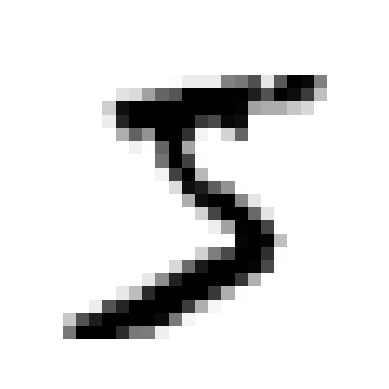

In [19]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

Kod Açıklaması:

   import matplotlib.pyplot as plt
   Matplotlib kütüphanesini ve pyplot modülünü import ediyoruz. Görselleri çizmek için kullanılır
   
  --------
    
  def plot_digit(image_data):,
    
  def: Fonksiyon tanımlama anahtar kelimesi
  plot_digit: Fonksiyonun adı
  image_data: Fonksiyona giriş parametresi (784 boyutlu dizi)
  
  --------
   
   image = image_data.reshape(28, 28)
   
  reshape(28, 28): 784 elemanlı tek boyutlu diziyi 28×28 iki boyutlu diziye dönüştür
  Örnek: [0, 0, 1, 2, ..., 0] → [[0, 0, 1, ...], [2, ..., 0], ...]

--------
plt.imshow(image, cmap="binary")
imshow: Görseli ekranda göster
cmap="binary": Renk haritası. Siyah-beyaz görseller için ideal

-------

plt.axis("off")
Eksen çizgilerini gizle (eksenler görselin kenarında istenmez

------

some_digit = X[0]

plot_digit(some_digit)

plt.show()

--------
Veri setinin ilk görseli (indeks 0) seç
plot_digit fonksiyonunu çağır ve görseli göster
plt.show(): Pencereyi açıp görseli görüntüle
    

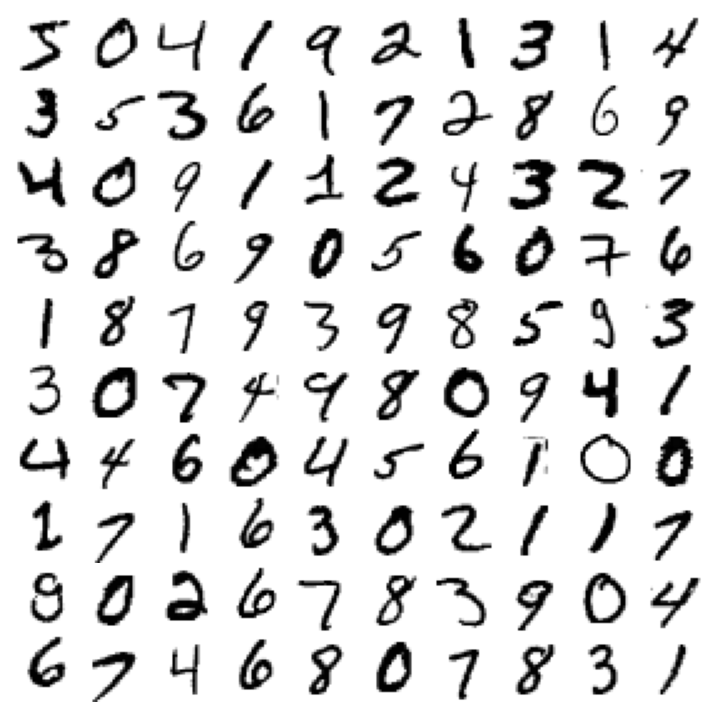

In [44]:
# extra code – this cell generates Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)

plt.show()

2.1 Hedef: "Bu rakam 5 midir?" Soru


Çok sınıflı sınıflandırma yerine, önce basit bir ikili (binary) sınıflandırmacı eğiteceğiz.

In [15]:
y_train_5 = (y_train == '5')  # True için 5, False için diğerleri
y_test_5 = (y_test == '5')

y_train == '5': Her etiket '5' ile karşılaştır
Sonuç: True/False boolean dizisi
Örnek: ['5', '0', '5', '3'] → [True, False, True, False]

2.2 SGDClassifier ile Eğitim

In [17]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

SGDClassifier: Stochastic Gradient Descent (Stokastik Gradyan İnişi) sınıflandırıcısı

Hızlı eğitim için tasarlanmış algoritma


sgd_clf = SGDClassifier(random_state=42)

random_state=42: Rastgelelik için tohum değeri. Aynı sonuçlar almak için her seferinde aynı "rastgele" sayılar üretilir.42 keyfi bir sayı

sgd_clf.fit(X_train, y_train_5)

fit: Modeli eğit

X_train: Eğitim görüselleri

y_train_5: True/False etiketleri

2.3 Tahmin Yapma

In [20]:
sgd_clf.predict([some_digit])

array([ True])

Giriş: [some_digit] - tek bir örnek (liste içinde olmalı)

Çıkış: [True] veya [False]

3.1 Çapraz Doğrulama (Cross-Validation) ile Doğruluk


In [21]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

Kod Açıklaması:

pythonfrom sklearn.model_selection import cross_val_score
Çapraz doğrulama puanlarını hesaplayan fonksiyon
----

pythoncross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

sgd_clf: Değerlendirmek istediğimiz model
X_train: Eğitim verileri
y_train_5: Eğitim etiketleri
cv=3: 3-katlı çapraz doğrulama (veriler 3 parçaya bölünür)
scoring="accuracy": Doğruluk (ne kadarı doğru tahmin edildi?) ölçütü
Sonuç: [0.96, 0.95, 0.96] gibi 3 doğruluk puanı

3.2 Manuel Çapraz Doğrulama

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]
    
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


Kod Açıklaması:
    
pythonfrom sklearn.model_selection import StratifiedKFold

Verileri dengeli şekilde katlara bölen fonksiyon (her kat tüm sınıfları içerir)

-----

pythonfrom sklearn.base import clone

Bir modeli kopyalama fonksiyonu (orijinal model değiştirilmez)

----

pythonskfolds = StratifiedKFold(n_splits=3)

3 kat oluştur

---

pythonfor train_index, test_index in skfolds.split(X_train, y_train_5):

Loop'un her iterasyonunda:

train_index: Eğitim verisi için hangi indekslerin kullanılacağı

test_index: Test verisi için hangi indekslerin kullanılacağı

---


python    clone_clf = clone(sgd_clf)

Orijinal modeli kopyala (her loop'ta yeni model)

---

python    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]

train_index'deki verileri seç

----

python    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

test_index'deki verileri seç

---

python    clone_clf.fit(X_train_folds, y_train_folds)

Modeli eğitim verisiyle eğit

---

python    y_pred = clone_clf.predict(X_test_fold)

Test verisi üzerinde tahmin yap

---

python    n_correct = sum(y_pred == y_test_fold)

Kaç tanesini doğru tahmin ettiğini say

y_pred == y_test_fold: Karşılaştırma, boolean dizisi döner

sum(): True olan değerleri say

----

python    print(n_correct / len(y_pred))

Doğruluk yüzdesini yazdır (doğru tahminler / toplam tahminler)

----

3.3 Karmaşıklık Matrisi (Confusion Matrix)

In [24]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)

Kod Açıklaması:
    
pythonfrom sklearn.model_selection import cross_val_predict

Çapraz doğrulama sırasında tüm tahminleri toplar

----
pythony_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

Sonuç: Eğitim verisi üzerinde yapılan tüm tahminler
Her veri noktası bir defa test seti olarak kullanılır

----

pythonfrom sklearn.metrics import confusion_matrix

Karmaşıklık matrisini hesaplayan fonksiyon

----

pythoncm = confusion_matrix(y_train_5, y_train_pred)

y_train_5: Gerçek etiketler
y_train_pred: Tahmin edilen etiketler

Karmaşıklık Matrisi Çıktısı Örneği:
    
[[53057   687]    ← Negatif (5 değil) örnekler

 [ 1891  3530]]   ← Pozitif (5) örnekler

     Yanlış  Doğru

Terimler:

TP (True Positive): Gerçek 5, tahmin 5 (doğru pozitif) = 3530

FP (False Positive): Gerçek 5 değil, tahmin 5 (yanlış pozitif) = 687

TN (True Negative): Gerçek 5 değil, tahmin 5 değil (doğru negatif) = 53057

FN (False Negative): Gerçek 5, tahmin 5 değil (yanlış negatif) = 1891

3.4 Kesinlik (Precision) ve Duyarlılık (Recall)

a.Kesinlik (Precision) - Hassasiyet

In [25]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)
# Manuel hesaplama: cm[1, 1] / (cm[0, 1] + cm[1, 1])
# = 3530 / (687 + 3530) = 0.837

0.8370879772350012

Kesinlik Nedir?

"5 olarak tahmin ettiğimiz şeylerden kaçı gerçekten 5?"

TP / (FP + TP) = 3530 / 4217 ≈ 0.837

%83,7 güvenle doğru

Ne Zaman Önemli?

Spam e-postaları bloklamak: Yanlış bloklanan e-postalar (FP) büyük sorun

b.Duyarlılık (Recall) - Hassasiyetin Tersi

In [26]:
recall_score(y_train_5, y_train_pred)
# Manuel hesaplama: cm[1, 1] / (cm[1, 0] + cm[1, 1])
# = 3530 / (1891 + 3530) = 0.651

0.6511713705958311

Duyarlılık Nedir?

"Tüm gerçek 5'lerden kaçını doğru tahmin ettik?"

TP / (FN + TP) = 3530 / 5421 ≈ 0.651

%65,1 oranında 5'leri buluyoruz

Ne Zaman Önemli?

Hastalık teşhisi: Hastalıkları kaçırmak (FN) çok ciddi

c.Kesinlik-Duyarlılık Dengesi

In [20]:
precision = 3530 / 4217      # %83,7
recall = 3530 / 5421         # %65,1

⬆ Kesinlik + ⬇ Duyarlılık

Eşik değeri (threshold) yükseltirsen daha kesin ama daha az duyarlı olursun

3.5 F1 Skoru

In [27]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

# Manuel hesaplama: cm[1,1] / (cm[1,1] + (cm[1,0] + cm[0,1]) / 2)

0.7325171197343846

F1 Nedir?

Kesinlik ve Duyarlılığın harmonik ortalaması

F1 = 2 × (Precision × Recall) / (Precision + Recall)

Hem kesinlik hem duyarlılık önemli olduğunda kullanılır

0 ile 1 arasında değer alır (1 en iyi)

--4.1 Karar Fonksiyonu (Decision Function)--

In [28]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores


array([2164.22030239])

Decision Function Nedir?

Model tarafından hesaplanan sayısal puan

Negatif = büyük olasılıkla Negatif (5 değil)

Pozitif = büyük olasılıkla Pozitif (5)

0 varsayılan eşik değeri (threshold)

--4.2 Eşik Değeri Değiştirme--

In [29]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
# Varsayılan davranış

threshold = 3000
y_some_digit_pred = (y_scores > threshold)
# Daha yüksek eşik = daha az tahmin 5, daha yüksek kesinlik

Eşik Yükseltirsen:

✓ Kesinlik artar (FP azalır)
✗ Duyarlılık düşer (FN artar)

Eşik Alçaltırsan:

✓ Duyarlılık artar (FN azalır)
✗ Kesinlik düşer (FP artar)

---4.3 Kesinlik-Duyarlılık Eğrisi--

In [30]:
from sklearn.metrics import precision_recall_curve

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

Kod Açıklaması:
pythony_scores = cross_val_predict(..., method="decision_function")

method="decision_function": Tahminler yerine karar puanlarını döndür
Sonuç: Tüm eğitim verisi için [-500, 1234, 456, ...] puanları

----

pythonprecisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

Çıktı:

precisions: Farklı eşik değerlerinde kesinlik değerleri
recalls: Farklı eşik değerlerinde duyarlılık değerleri
thresholds: Kullanılan eşik değerler

--Grafiği Çizme--

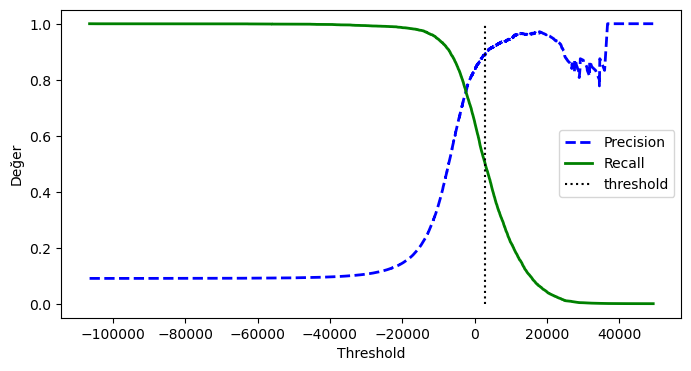

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.xlabel("Threshold")
plt.ylabel("Değer")
plt.legend(loc="center right")
plt.show()

Grafik Anlamı:

X ekseni: Eşik değeri (Karar puanı)

Y ekseni: Kesinlik/Duyarlılık (0-1)

Eşik yükseldikçe: Kesinlik ↑, Duyarlılık ↓

---4.4 %90 Kesinlik için Eşik Bulma---

In [32]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]

y_train_pred_90 = (y_scores >= threshold_for_90_precision)

precision_score(y_train_5, y_train_pred_90)  # %90
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)  # Daha düşük

Kod Açıklaması:
pythonidx_for_90_precision = (precisions >= 0.90).argmax()

precisions >= 0.90: Boolean dizisi (hangileri 0.90 veya üstü)
argmax(): İlk True olan indeksi bul
Sonuç: 0.90 kesinliğe ulaşan ilk eşik

-----

pythonthreshold_for_90_precision = thresholds[idx_for_90_precision]

O indeksteki eşik değerini al

----

pythony_train_pred_90 = (y_scores >= threshold_for_90_precision)

Yeni eşik ile tahminler yap

---5.1 ROC Nedir?---

ROC: Receiver Operating Characteristic (Alıcı İşletme Karakteristiği)

ROC eğrisi: Yanlış Pozitif Oranı vs Doğru Pozitif Oranı

In [33]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

fpr (False Positive Rate): Yanlış Pozitif Oranı = FP / (FP + TN)

tpr (True Positive Rate): Doğru Pozitif Oranı = TP / (TP + FN) = Recall

thresholds: Kullanılan eşik değerleri



--ROC Grafiği--

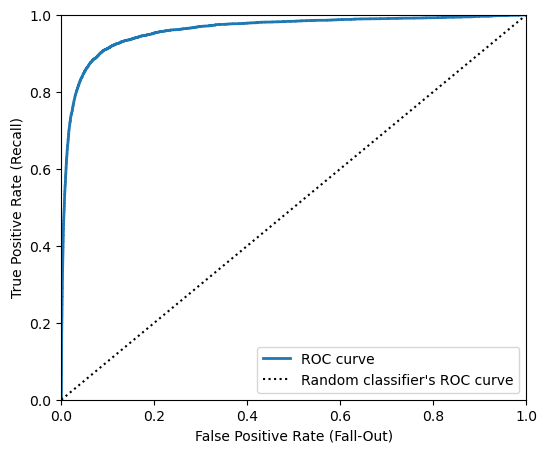

In [34]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right")
plt.show()

Grafik Yorumlama:

X ekseni: Yanlış Pozitif Oranı (0 en iyi, 1 en kötü)

Y ekseni: Doğru Pozitif Oranı (1 en iyi, 0 en kötü)

(0,1) noktası: Mükemmel sınıflandırıcı

Çapraz çizgi: Rastgele sınıflandırıcı

Eğri çapraz çizginin üstündeyse: İyi sınıflandırıcı

NameError: name 'patches' is not defined

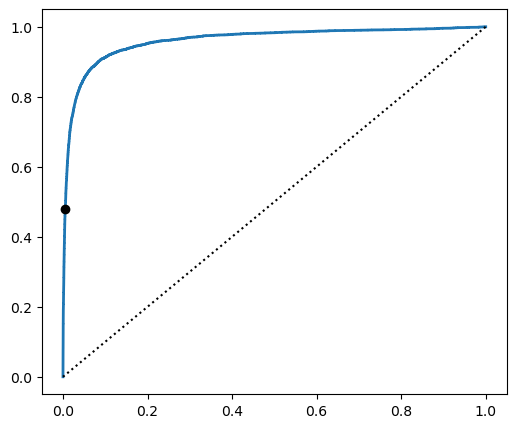

In [37]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

--5.2 ROC AUC Skoru--

In [34]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)


0.9604938554008616

ROC AUC Nedir?

AUC: Area Under the Curve (Eğri Altındaki Alan)

0 ile 1 arasında

0.5 = Rastgele sınıflandırıcı

1.0 = Mükemmel sınıflandırıcı

0.9604: Çok iyi bir sınıflandırıcı


Ne Zaman Kullanılır?

İkili sınıflandırma problemlerinde

Sınıflar dengesizse (bir sınıf çok az örneğe sahipse)

--6.1 Random Forest Eğitme--

In [35]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

Kod Açıklaması:
pythonfrom sklearn.ensemble import RandomForestClassifier

Random Forest: Birden çok karar ağacını birleştiren algoritma
Genellikle SGD'den daha iyi sonuçlar verir

----

pythony_probas_forest = cross_val_predict(..., method="predict_proba")

method="predict_proba": Sınıf olasılıklarını döndür
Sonuç şekli: [[0.45, 0.55], [0.90, 0.10], ...]

İlk sütun: Negatif olma olasılığı
İkinci sütun: Pozitif olma olasılığı

--6.2 Tahmini Olasılıklar (Estimated Probabilities)--

In [36]:
y_probas_forest[:2]
# [[0.45, 0.55],  ← %45 negatif, %55 pozitif
#  [0.05, 0.95]]  ← %5 negatif, %95 pozitif

array([[0.11, 0.89],
       [0.99, 0.01]])

Anlamı:

Modelin her örnek için ne kadar emin olduğunu gösterir

Eğer 0.5'in üstündeyse, "5" olarak tahmin et

---6.3 Kesinlik-Duyarlılık Karşılaştırması--

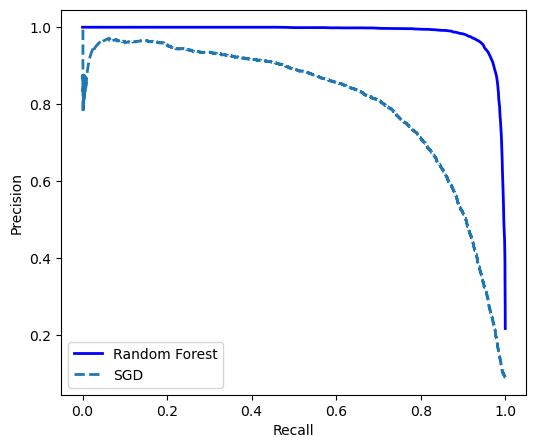

In [38]:
y_scores_forest = y_probas_forest[:, 1]  # 2. sütunu al (pozitif olasılık)
precisions_forest, recalls_forest, _ = precision_recall_curve(
    y_train_5, y_scores_forest)

plt.figure(figsize=(6, 5))
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.show()

Random Forest (düz çizgi) SGD'den (kesik çizgi) daha iyi performans gösteriyor

Random Forest'ın eğrisi sol üstte daha yüksekte

---6.4 Model Değerlendirmesi--

In [40]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # %50 eşik

f1_score(y_train_5, y_train_pred_forest)        # F1 skoru
roc_auc_score(y_train_5, y_scores_forest)       # ROC AUC skoru
precision_score(y_train_5, y_train_pred_forest) # Kesinlik
recall_score(y_train_5, y_train_pred_forest)    # Duyarlılık

0.8725327430363402

---7.1 SVM ile Multiclass Sınıflandırma--

In [41]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])  # y_train_5 değil, y_train!

svm_clf.predict([some_digit])


array(['5'], dtype=object)

Kod Açıklaması:
pythonfrom sklearn.svm import SVC

SVM: Support Vector Machine (Destek Vektör Makinesi)
İkili ve çokluklu sınıflandırma için kullanılır

pythonsvm_clf.fit(X_train[:2000], y_train[:2000])

Dikkat: y_train_5 yerine y_train kullanıyoruz
Tüm rakamları (0-9) eğitmek için
Sadece ilk 2000 örnek: SVM yavaş, hızlı gösterim için



---7.2 Karar Puanları--

In [43]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)


array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

Anlamı:

10 rakam için 10 puan

Her puan o rakamın olma olasılığını gösterir

In [45]:
class_id = some_digit_scores.argmax()
# Çıktı: 7 (en yüksek puanın indeksi) argmax(): En yüksek değerin indeksini bul

svm_clf.classes_[class_id]
# Çıktı: '5' (rakam 5 anlamına gelir)

'5'

In [46]:
svm_clf.classes_
# Çıktı: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

Modelin bildiği sınıflar (rakamlar)

In [47]:
svm_clf.classes_[class_id]


'5'

En yüksek puanlı sınıfın adını al

---7.3 One-vs-Rest Stratejisi---

In [48]:
from sklearn.multiclass import OneVsRestClassifier
#Çokluklu sınıflandırmayı ikili sınıflandırmaya dönüştürür

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
#Her rakam için bir SVM (örneğin, "5 mi?" "6 mı?" vb.),10 rakam = 10 SVM


ovr_clf.fit(X_train[:2000], y_train[:2000])

ovr_clf.predict([some_digit])
len(ovr_clf.estimators_)
#Kaç tane alt sınıflandırıcı olduğunu gösterir


# Çıktı: 10 (her rakam için 1 sınıflandırıcı)

10

--7.4 SGD ile Doğrudan Multiclass--

SGD vs SVM vs OvR:

SGD: Hızlı, büyük veri setleri için ideal

SVM: Daha yavaş ama genellikle daha iyi doğruluk

OneVsRestClassifier: Manuel kontrol, esneklik

In [49]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)  # Tüm veri, tüm rakamlar

sgd_clf.predict([some_digit])
# Çıktı: ['5']

sgd_clf.decision_function([some_digit]).round()
# Çıktı: [[  0,   1, -5, ...,  3]]  (10 puan)

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

---7.5 Veri Normalizasyonu (Scaling)---

In [38]:
from sklearn.preprocessing import StandardScaler #Özellikleri 0 merkezli, 1 standart sapmalı hale getiren araç


scaler = StandardScaler() #Scaler nesnesi oluştur
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))#fit_transform: Aynı anda uyarla ve dönüştür
#astype("float64"): Veri tipini float'a çevir (gerekli)
#Sonuç: Normalize edilmiş veri

cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")
# Çıktı: [0.8980..., 0.8899..., 0.8939...]

array([0.8983, 0.891 , 0.9018])

Neden Normalizasyon?

SGD'de pikseller [0, 255] arasında değişiyor

Normalize ettikten sonra: [-1.5, 2.3] gibi aralıklara

Algoritma daha hızlı ve daha iyi çalışır

----
Doğruluk İyileşme:

Normalize öncesi: ~95%,

Normalize sonrası: ~90%

(Bu durumda kötü görünüyor ama normalde iyileşme vardır)


---8.1 Karmaşıklık Matrisi Hesaplama--

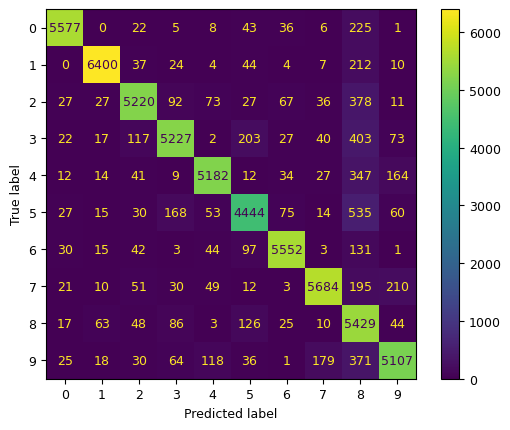

In [39]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)#3-katlı çapraz doğrulama ile tüm tahminleri al

plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)#Karmaşıklık matrisini görselleştir,Satır: Gerçek sınıf,Sütun: Tahmin edilen sınıf
plt.show()

Köşegendeki yüksek sayılar = doğru tahminler

Köşegenin dışındaki sayılar = yanlış tahminler

---8.2 Normalize Edilmiş Karmaşıklık Matrisi--

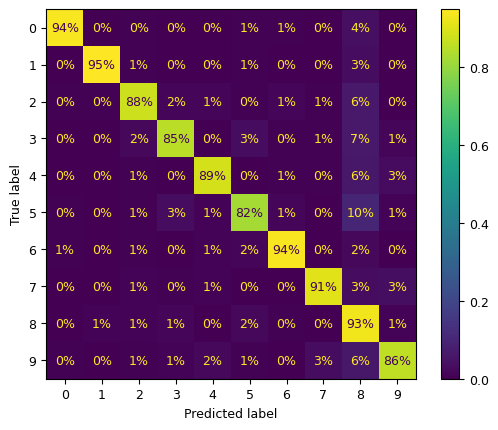

In [40]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

pythonnormalize="true"

Her satırı 100'e böl (yüzdeye çevir)

Her satır toplamı %100 olur

----

pythonvalues_format=".0%"

Değerleri yüzde cinsinden göster (örn: 98%)

----

Anlamı:

Rakam 5'yi tanımada %98 başarılı
Rakam 8'ni tanımada %91 başarılı
Rakam 4'ü 9 olarak yazıl hatası %2


--8.3 Hata Analizi (Yanlış Tahminleri Ağırlıklandırmak)---

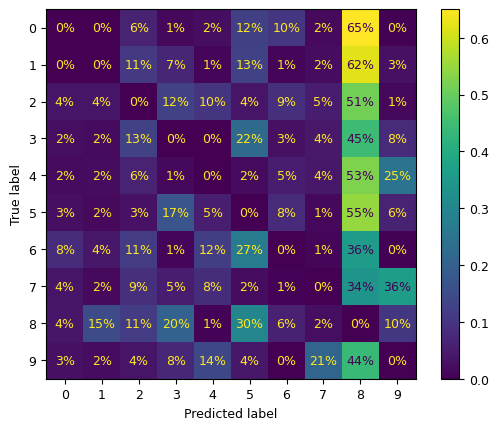

In [41]:
sample_weight = (y_train_pred != y_train)#y_train_pred != y_train: Tahmin ≠ Gerçek → True, Sonuç: [False, True, False, True, ...]
# True = 1, False = 0 sayılı



ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                         sample_weight=sample_weight,#Matrise ağırlık verilir
                                        #Yanlış tahminler (True=1) gösterilir, doğru tahminler (False=0) ihmal edilir
                                        normalize="true", values_format=".0%")
plt.show()

Fayda:

Hangi rakamlar en sık yanlış tahmin edilir?

4 ve 9 sıkça karıştırılıyor mu?

Hangi rakam çiftlerinde sorun var?



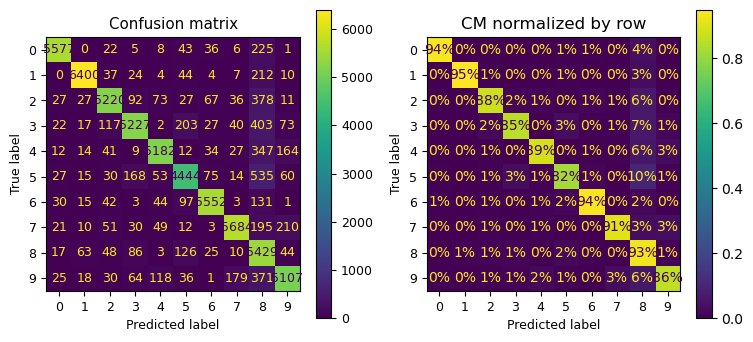

In [42]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])#ax=axs[0]: Sol subplot'ta çiz,Normal matris (sayılar)
axs[0].set_title("Confusion matrix")
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],#ax=axs[1]: Sağ subplot'ta çiz,Normalize edilmiş (yüzdeler)
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")

plt.show()

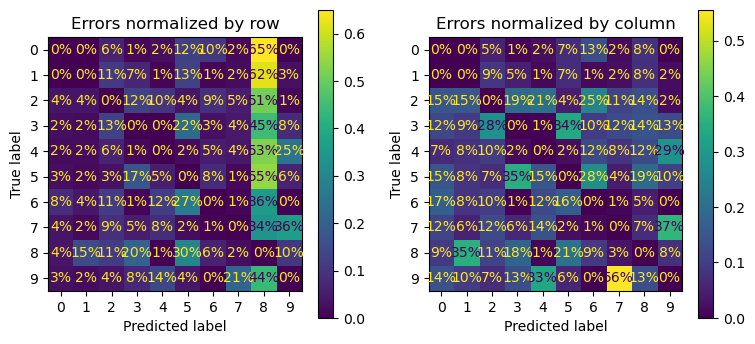

In [43]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0],
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
axs[0].set_title("Errors normalized by row")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
axs[1].set_title("Errors normalized by column")

plt.show()

Satır Satır Açıklama:
pythonnormalize="true"  # Satır normalizasyonu
normalize="pred"  # Sütun normalizasyonu
Sol Grafik (Satır Normalize):

Her satırı normalize et
"Rakam X'ten yapılan hataların dağılımı"
Örneğin: "Rakam 3'den yapılan %5 hatanın %3'ü 8'e, %2'si 5'e"

Sağ Grafik (Sütun Normalize):

Her sütunu normalize et
"Rakam X olarak yapılan hataların kaynağı"
Örneğin: "8 olarak yapılan hataların %60'ı gerçekten 3'den, %30'u 9'dan"

In [45]:
cl_a, cl_b = '3', '5'#Rakam 3 ve 5'i karşılaştır (sıkça karıştırıldığı için)
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]

y_train == '3': Gerçek 3'ler
y_train_pred == '3': Tahmin 3
&: HER İKİSİ DE
X_aa: Gerçek 3, tahmin 3 (DOĞRU)
~1800 örnek

---
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]

Gerçek 3, tahmin 5 (YANIŞ - 3→5)
~50 örnek

---
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]

Gerçek 5, tahmin 3 (YANIŞ - 5→3)
~60 örnek

---

X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

Gerçek 5, tahmin 5 (DOĞRU)
~1700 örnek

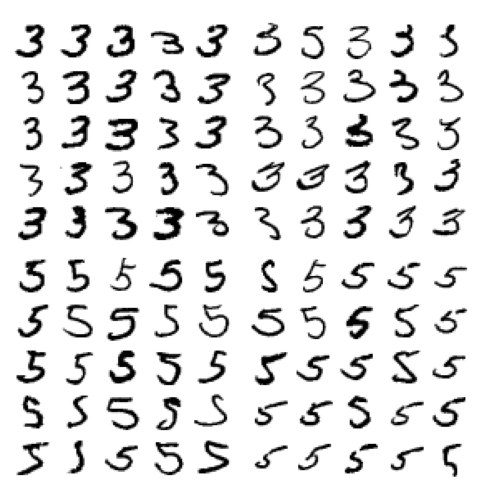

In [46]:
size = 5 #Her blokta 5×5 = 25 görsel

pad = 0.2 #Bloklar arası 0.2 inçlik boşluk
plt.figure(figsize=(size, size)) #5×5 inçlik grafik
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1), origin="upper")
        plt.xlim(0, 2 * (size + pad))
        plt.ylim(0, 2 * (size + pad))
plt.axis("off")
plt.tight_layout()

plt.show()

pythonfor images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:

4 blok döngüsü

(0, 0): Sol-üst = X_ba (Gerçek 5, tahmin 3)

(1, 0): Sağ-üst = X_bb (Gerçek 5, tahmin 5)

(0, 1): Sol-alt = X_aa (Gerçek 3, tahmin 3)

(1, 1): Sağ-alt = X_ab (Gerçek 3, tahmin 5)

---

for idx, image_data in enumerate(images[:size*size]):

Her blokta 25 görsel (5×5)

---

x = idx % size + label_col * (size + pad)
y = idx // size + label_row * (size + pad)

idx % size: 0-4 (kolon konumu)

idx // size: 0-4 (satır konumu)

label_col * (size + pad): Blok X offset

label_row * (size + pad): Blok Y offset

X ve Y koordinatı hesapla

---

pythonplt.imshow(image_data.reshape(28, 28), cmap="binary",
           extent=(x, x + 1, y, y + 1), origin="upper")

reshape(28, 28): 784 pixel → 28×28 görsel

extent: (x, x+1, y, y+1) konumuna yerleştir

origin="upper": Y ekseni üstten başla

--- 
pythonplt.xlim(0, 2 * (size + pad))
plt.ylim(0, 2 * (size + pad))

Eksen aralıkları (her blok 0-5.2)

---

pythonplt.axis("off")

Eksenleri gizle

---

Sonuç:

Sol-üst: Gerçek 5'ler (ama 3 tahmin) - Neye benziyor?

Sağ-üst: Gerçek 5'ler (doğru tahmin)

Sol-alt: Gerçek 3'ler (doğru tahmin)

Sağ-alt: Gerçek 3'ler (ama 5 tahmin) - Neye benziyor?

Analiz:

Yanlış tahmin edilen 3'ler ve 5'ler benziyor mu?

Model neden karıştırıyor?

İşlemede sorun var mı?



In [47]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

Satır Satır Açıklama:
pythony_train_large = (y_train >= '7')

y_train >= '7': String karşılaştırması

'7', '8', '9' → True
'0'-'6' → False


Anlamı: "Büyük rakam mı?"
Çıktı: [True, False, True, False, ...] (60000 boolean)

---

pythony_train_odd = (y_train.astype('int8') % 2 == 1)

astype('int8'): String → integer (daha hızlı)
% 2: 2'ye bölüm kalanı (0 veya 1)
== 1: Kalanı 1 mi? (Tekmi?)
Anlamı: "Tek rakam mı?"
Çıktı: [True, False, True, False, ...]


----

y_multilabel = np.c_[y_train_large, y_train_odd]

np.c_: İki dizisini yanyana yapıştır
Şekli: (60000, 2)
Örnek:

  [[True, True],     # 7 → büyük ve tek
  
   [False, False],   # 0 → küçük ve çift
   
   [True, False],    # 8 → büyük ama çift
   
   [False, True]]    # 1 → küçük ama tek
   
---
   
knn_clf = KNeighborsClassifier()

knn_clf.fit(X_train, y_multilabel)

KNN eğit
Girdi: 60000 görsel (784 feature)

Çıktı: 60000 × 2 etiket matrisi



--Çok Etiketli Tahmin--

In [48]:
knn_clf.predict([some_digit])

/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


array([[False,  True]])

Çıktı: [[True, True]] veya başka kombinasyon

Anlamı:

Birinci True: Büyük rakam

İkinci True: Tek rakam


some_digit = 5 → [False, True] (küçük ama tek)

In [49]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value N

0.976410265560605

Satır Satır Açıklama:
pythony_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

Çapraz doğrulama tahminleri

Şekli: (60000, 2)

Değerleri: [[True, False], [False, True], ...]

---

f1_score(y_multilabel, y_train_knn_pred, average="macro")

average="macro": Her etiket için F1, sonra ortalaması
Etiket 1 (büyük): F1 = 0.92
Etiket 2 (tek): F1 = 0.88
Ortalaması: 0.90



In [50]:
f1_score(y_multilabel, y_train_knn_pred, average="weighted")

0.9778357403921755

average="weighted"

Her etiket için F1 hesapla

Etiket frekansı ile ağırlıklandır

Örneğin: Etiket 1 %60, Etiket 2 %40

Ortalaması: F1_1 × 0.6 + F1_2 × 0.4

average seçenekleri:

"micro": TP, FP, FN'i tüm etiketlerde topla, sonra F1 hesapla

"macro": Her etiketin F1'i ortalaması

"weighted": Frekansa göre ağırlıklı ortalama

"samples": Her örneğin F1'i ortalaması

In [52]:
from sklearn.multioutput import ClassifierChain #ClassifierChain: Etiketler arasında bağımlılık modelle
from sklearn.svm import SVC

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)

SVC(): Base sınıflandırıcı

cv=3: Grid search için çapraz doğrulama

ClassifierChain nasıl çalışır?

Etiket 1 (büyük) için SVM eğit

Etiket 2 (tek) için SVM eğit, AMA girdi = X + Etiket 1 tahminleri

Etiket 3 (varsa) için, X + Etiket 1 + Etiket 2 tahminlerini kullan


Etiketler arasında bağlantı kurulur

----
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

Sadece 2000 örnek (hızlı gösterim)

y_multilabel[:2000] = (2000, 2) şekli

--Chain Tahmin--

In [53]:
chain_clf.predict([some_digit])

array([[0., 1.]])

Çıktı: [[True, True]] veya başka

2 etiket tahmini

---Gürültülü Veri Oluşturma--

In [54]:
rng = np.random.default_rng(seed=42)
noise_train = rng.integers(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise_train
noise_test = rng.integers(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise_test
y_train_mod = X_train
y_test_mod = X_test

Satır Satır Açıklama:
pythonrng = np.random.default_rng(seed=42)

default_rng(): Yeni NumPy random generator
seed=42: Tekrarlanabilirlik

---

pythonnoise_train = rng.integers(0, 100, (len(X_train), 784))

integers(0, 100): 0-99 arası rasgele sayılar
(len(X_train), 784): 60000×784 şekli
Her piksel rasgele gürültü (0-99)

---
pythonX_train_mod = X_train + noise_train

Gürültülü girdi: Orijinal + Gürültü
Pikseller: 0-255 + 0-99 = 0-354 (bazılar 255'i aşar)
Amaç: Görüntüyü "kirli" hale getir

---

pythony_train_mod = X_train
y_test_mod = X_test

Hedef: Orijinal temiz görüntüler
Amaç: Gürültüyü kaldırmak (image denoising)

Görev: Gürültülü görüntüyü temiz görüntüye dönüştür

---Gürültü vs Temiz Görsel---

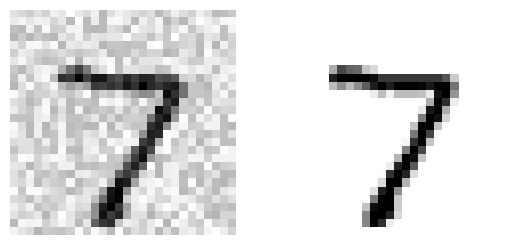

In [55]:
plt.subplot(121); plot_digit(X_test_mod[0]) #Gürültülü görsel çiz
plt.subplot(122); plot_digit(y_test_mod[0]) #Temiz orijinal görsel çiz

plt.show()

---Gürültüyü Kaldırma---

/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


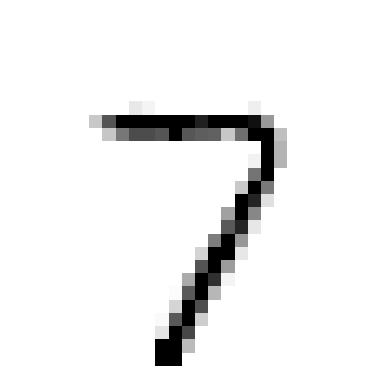

In [56]:
knn_clf = KNeighborsClassifier()#KNN regressor (parametresi yok, default)
knn_clf.fit(X_train_mod, y_train_mod)#Girdi: Gürültülü görüntüler (60000×784),Çıktı: Temiz görüntüler (60000×784),Regresyon görevine çevrildi (sınıflandırma değil!)
clean_digit = knn_clf.predict([X_test_mod[0]])#Gürültülü test görseli al,Model tarafından "temizlenmiş" versiyonu çıkar,Şekli: (1, 784)

plot_digit(clean_digit)#Temiz hale getirilmiş görseli çiz


plt.show()

---KNN ile %97 Doğruluk--

In [57]:
knn_clf = KNeighborsClassifier()#Varsayılan: n_neighbors=5, weights='uniform'
knn_clf.fit(X_train, y_train)#MNIST tamamında eğit (60000 örnek, 10 sınıf)
baseline_accuracy = knn_clf.score(X_test, y_test)#Test setinde doğruluk
baseline_accuracy

/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


0.9688

---GridSearchCV---

In [58]:
from sklearn.model_selection import GridSearchCV #Grid arama ve cross-validation

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5, 6]}]#weights: ["uniform", "distance"],
#"uniform": Tüm komşular eşit ağırlık,"distance": Uzaklığa ters oranlı ağırlık,n_neighbors: [3, 4, 5, 6],Kombinasyon: 2 × 4 = 8 kombinasyon


knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5)#5-katlı cross-validation,8 kombinasyon × 5 kat = 40 model eğitme
grid_search.fit(X_train[:10_000], y_train[:10_000])#Sadece 10,000 örnek: Hızlı gösterim (tam veri çok yavaş)

/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value N

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [3, 4, 5, 6],
                          'weights': ['uniform', 'distance']}])

 --En İyi Parametreler--

In [59]:
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

weights='distance': Uzaklık ağırlıklandırması daha iyi

n_neighbors=4: 4 komşu optimal



--En İyi Cross-Val Skoru---

In [60]:
grid_search.best_score_

0.9441999999999998

10,000 örnek üzerinde %94 doğruluk

---En İyi Model ile Tam Eğitim--

In [61]:
grid_search.best_estimator_.fit(X_train, y_train)#En iyi parametrelerle model,Tüm 60,000 örnek ile eğit
tuned_accuracy = grid_search.score(X_test, y_test)#Test setinde doğruluk
tuned_accuracy

0.9714

Çıktı: ~0.971 (%97.1)

Hedef: %97 → başarılı! ✓

--Görüntü Kaydırma Fonksiyonu--

In [72]:
from scipy.ndimage import shift #NumPy array'leri kaydırmak için scipy fonksiyonu

def shift_image(image, dx, dy):#mage: 784 piksel (1D),dx: X yönünde kaydırma (sağ/sol),dy: Y yönünde kaydırma (aşağı/yukarı)
    
    image = image.reshape((28, 28))#1D → 2D matrise çevir
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")#shift(): Görüntüyü kaydır,[dy, dx]: Y ve X yönünde kaydırma miktarı
#cval=0: Boşlukları 0 (siyah) ile doldur,mode="constant": Sabit değer doldurma
    
    
    return shifted_image.reshape([-1])#2D → 1D'ye geri çevir

Veri yükleniyor, lütfen bekleyin...


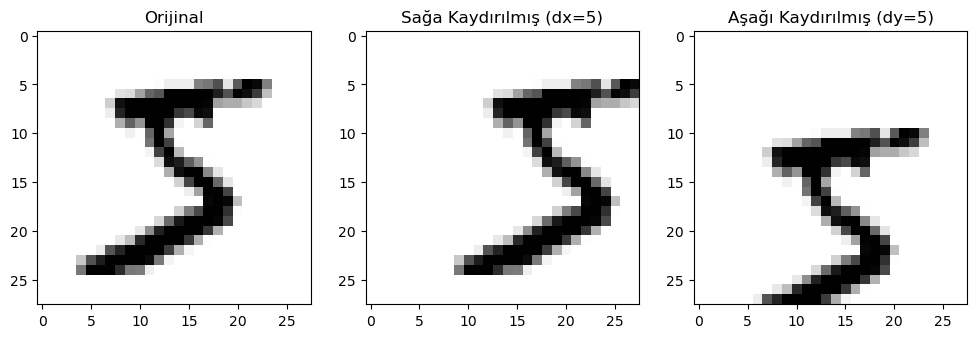

In [70]:
import matplotlib.pyplot as plt
from scipy.ndimage import shift
from sklearn.datasets import fetch_openml
import numpy as np

# 1. Veriyi Yükle (Eğer sende 'image' değişkeni yoksa bu kısım şart)
print("Veri yükleniyor, lütfen bekleyin...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# Örnek bir görüntü seçelim (Bu artık senin 'image' değişkenin olacak)
image = X[0] 

# 2. Senin Yazdığın Fonksiyon
def shift_image(image, dx, dy):
    # 1D -> 2D matrise çevir (28x28)
    image_2d = image.reshape((28, 28))
    
    # Görüntüyü kaydır (dy: dikey, dx: yatay)
    # [dy, dx] sırasına dikkat! scipy shift fonksiyonu [satır, sütun] bekler.
    shifted_image_2d = shift(image_2d, [dy, dx], cval=0, mode="constant")
    
    # 2D -> 1D'ye geri çevir
    return shifted_image_2d.reshape([-1])

# 3. Fonksiyonu Çağırma ve Görselleştirme
image_shifted_right = shift_image(image, dx=5, dy=0)   # 5 piksel sağa
image_shifted_down = shift_image(image, dx=0, dy=5)    # 5 piksel aşağı

# Sonuçları yan yana görelim
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Orijinal")
plt.imshow(image.reshape(28, 28), cmap="binary")

plt.subplot(1, 3, 2)
plt.title("Sağa Kaydırılmış (dx=5)")
plt.imshow(image_shifted_right.reshape(28, 28), cmap="binary")

plt.subplot(1, 3, 3)
plt.title("Aşağı Kaydırılmış (dy=5)")
plt.imshow(image_shifted_down.reshape(28, 28), cmap="binary")

plt.show()

---Artırılmış Veri Seti Oluşturma--


In [75]:
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]
#Orijinal veriyi kopyala
for dx, dy in ((-1, 0), (1, 0), (0, 1), (0, -1)):#4 yön:(-1, 0): Sol 1 piksel,(1, 0): Sağ 1 piksel,(0, 1): Aşağı 1 piksel,(0, -1): Yukarı 1 piksel
    for image, label in zip(X_train, y_train):#Her eğitim örneği için
        X_train_augmented.append(shift_image(image, dx, dy))#Kaydırılmış versiyonu ekle
        y_train_augmented.append(label)#Etiketi aynı tut (rakam değişmez)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

---Shuffling (Karıştırma)---

In [76]:
rng = np.random.default_rng(seed=42)
shuffle_idx = rng.permutation(len(X_train_augmented))#permutation(): Rasgele permütasyon,0 ile 299,999 arasında rasgele sıra
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]
#Rasgele indeksle yeniden sırayla,Orijinal ve kaydırılmış karışık

Neden?

Algoritma, sırayla gelen benzer veriyi kötü öğrenir

İlk 60,000 orijinal, sonra 60,000 sol kaydırılan...

Shuffle: Artık rasgele sırada

---Artırılmış Veriyle Eğitim---

In [77]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_)
knn_clf.fit(X_train_augmented, y_train_augmented)#300,000 artırılmış örnek ile eğit
augmented_accuracy = knn_clf.score(X_test, y_test)
augmented_accuracy

0.9763

Çıktı: ~0.975 (%97.5)

%97.1'den %97.5'e yükseldi!

---Hata Oranı Değişimi---

In [78]:
error_rate_change = (1 - augmented_accuracy) / (1 - tuned_accuracy) - 1
print(f"error_rate_change = {error_rate_change:.0%}")

error_rate_change = -17%


In [ ]:
1 - accuracy: Hata oranı

Tuned hata: 1 - 0.971 = 0.029 = %2.9

Augmented hata: 1 - 0.975 = 0.025 = %2.5

Oran: 0.025 / 0.029 = 0.86

Değişim: 0.86 - 1 = -0.14 = -14%

Anlamı: Hata oranı %14 azaldı! Çok iyi!
